In [128]:
# Import Libraries and Configure Matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import re
import collections
from matplotlib import cm
from matplotlib import colors
from pycirclize import Circos
from tqdm import tqdm
import glob
import pandas as pd
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.circ as circ
# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(circ)

<module 'utilities.circ' from '/Users/xuechenkan/potts_model_test/ms0.5/../utilities/circ.py'>

In [129]:
start_aa_IN = 1  # Starting amino acid position
actual_length_IN = 263
start_aa_PR = 1  # Starting amino acid position
actual_length_PR = 99
start_aa_RT = 39  # Starting amino acid position
actual_length_RT = 188
IN_path = '../ms0.5/IN/'
PR_path = '../ms0.5/PR/'
RT_path = '../ms0.5/RT/'
IN_unreduced_seq_path = IN_path + 'data/in.fullseq'
PR_unreduced_seq_path = PR_path + 'data/pr.exper.fullseq'
RT_unreduced_seq_path = RT_path + 'data/rt.fullseq'

IN_kn_path = IN_path+'data/kn.her2.all'
PR_kn_path = PR_path+'data/kn.her2.all'
RT_kn_path = RT_path+'data/kn.her2.all'

IN_redux_dict = functions.get_redu_dict(IN_path+'data/in.reduce4.redux',1)
PR_redux_dict = functions.get_redu_dict(PR_path+'data/pr.reduce4.redux',0)
RT_redux_dict = functions.get_redu_dict(RT_path+'data/rt.reduce4.redux',0)

top_20_DRM_IN = functions.read_list_from_file(IN_path + 'data/top_20_DRM.txt')
bottom_20_DRM_IN = functions.read_list_from_file(IN_path + 'data/bottom_20_DRM.txt')
combined_DRM_IN = top_20_DRM_IN + bottom_20_DRM_IN

top_20_DRM_PR = functions.read_list_from_file(PR_path + 'data/top_20_DRM.txt')
bottom_20_DRM_PR = functions.read_list_from_file(PR_path + 'data/bottom_20_DRM.txt')
combined_DRM_PR = top_20_DRM_PR + bottom_20_DRM_PR

top_20_DRM_RT = functions.read_list_from_file(RT_path + 'data/top_20_DRM.txt')
bottom_20_DRM_RT = functions.read_list_from_file(RT_path + 'data/bottom_20_DRM.txt')
combined_DRM_RT = top_20_DRM_RT + bottom_20_DRM_RT

width = 1.75
width_d2 = width/2
# scale_mode = 'color'
scale_mode = 'cw6'
# scale_mode = 'width'
scale_scale = 'global'
weight_power=2
a = 3
b = 0.4
x_min = 1.8230609
x_max = 33.17926


Max pair DDE sum: 33.17925, Key: (140, 148)
Min pair DDE sum: 3.15966, Key: (216, 221)


Processing background chords: 100%|██████████| 50/50 [00:00<00:00, 6064.99it/s]


max_dde: 8.50879


Processing background chords: 100%|██████████| 50/50 [00:00<00:00, 6270.26it/s]


min_dde: -3.18745


...

Chord out of range: region1=('IN', -0.15434085475948933, 0.15434085475948933), region2=('IN', 3.8456591452405107, 4.154340854759489)


max_dde: 8.50879


Processing background chords: 100%|██████████| 50/50 [00:00<00:00, 8944.60it/s]


min_dde: -2.2173753


Processing background chords: 100%|██████████| 40/40 [00:00<00:00, 8072.18it/s]


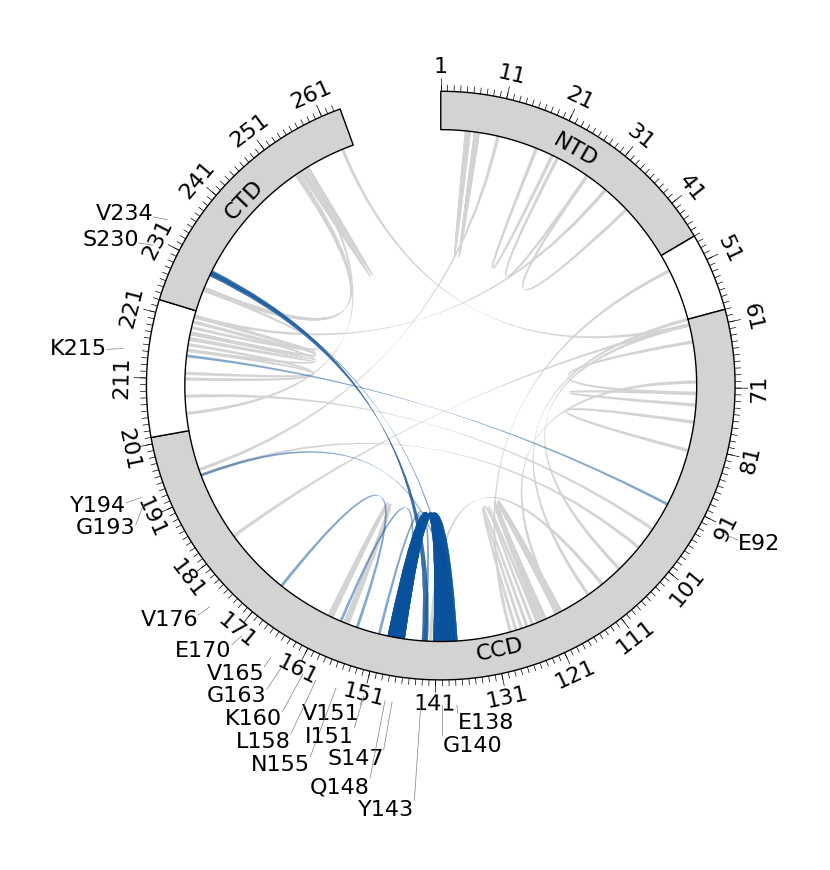

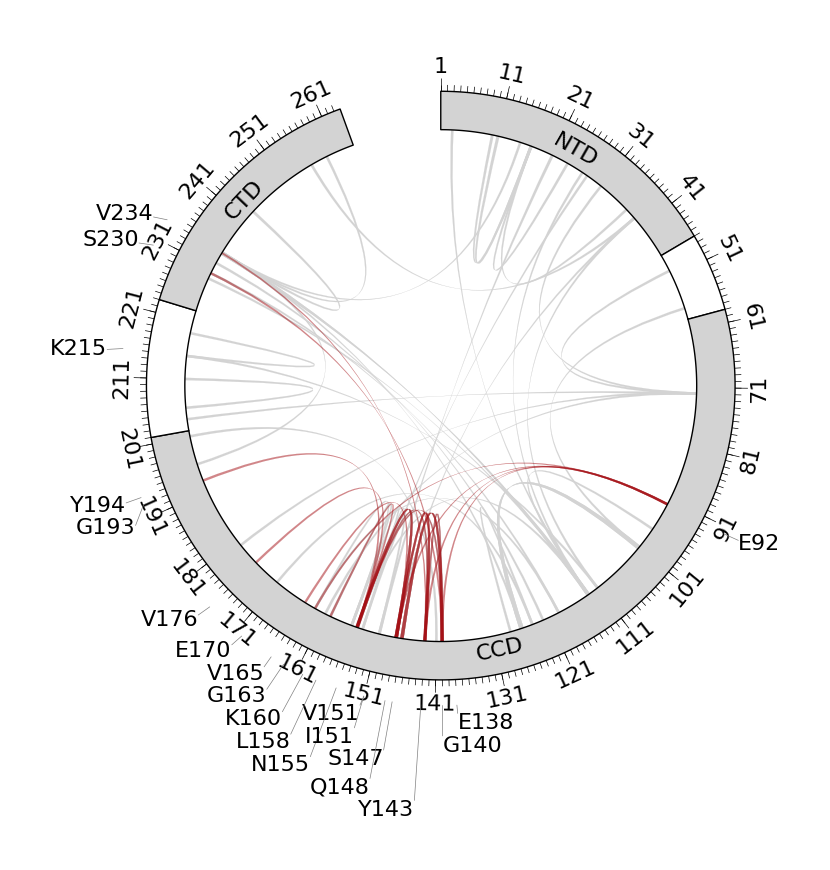

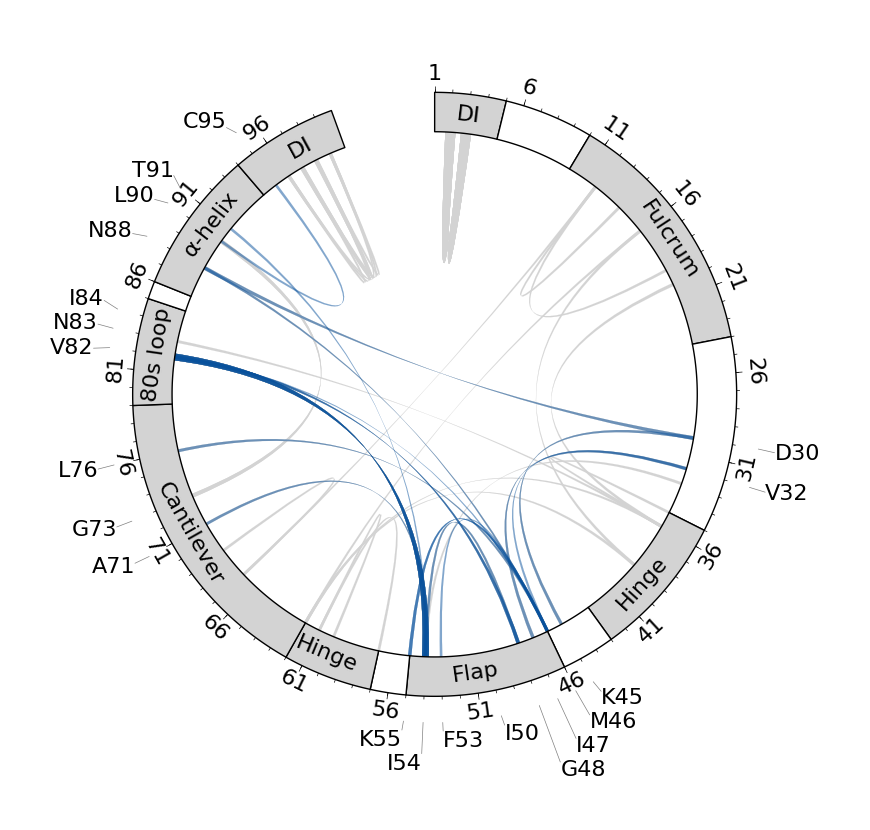

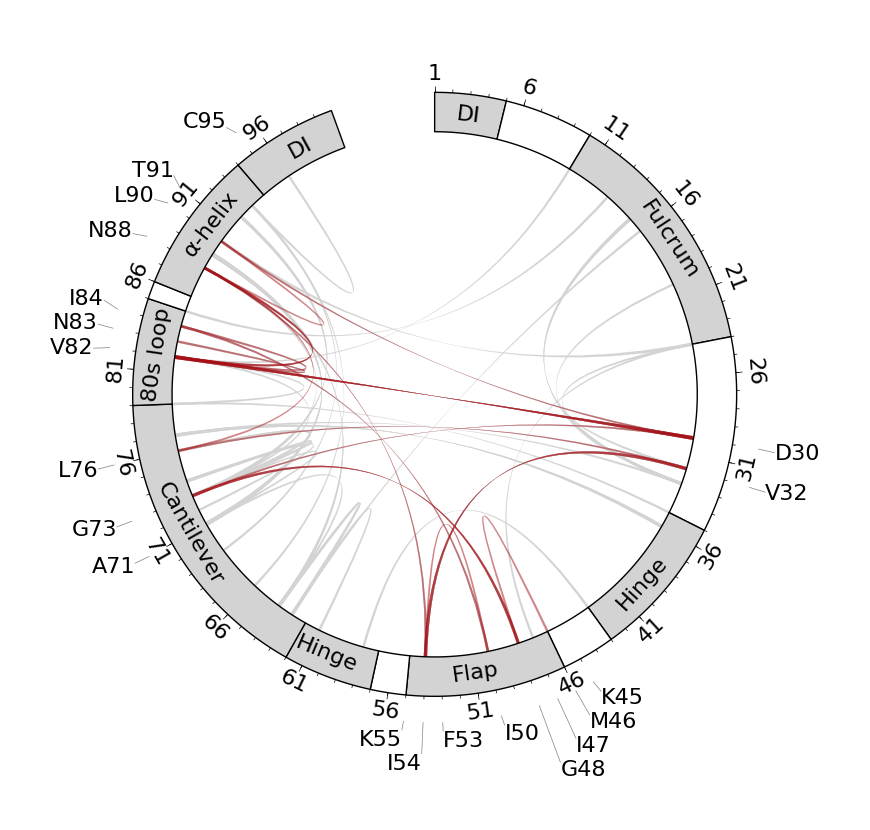

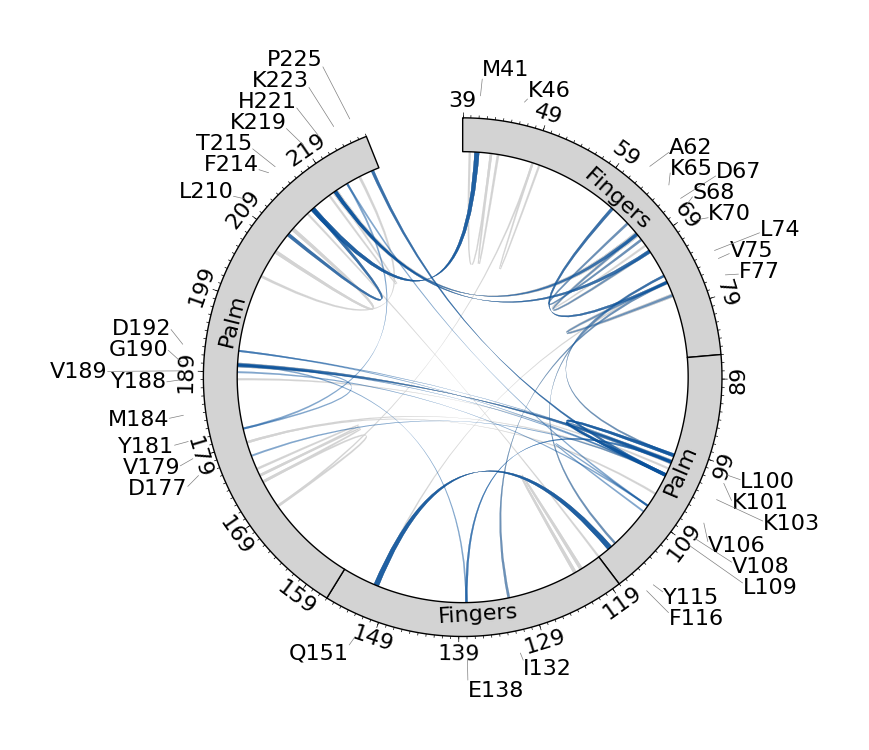

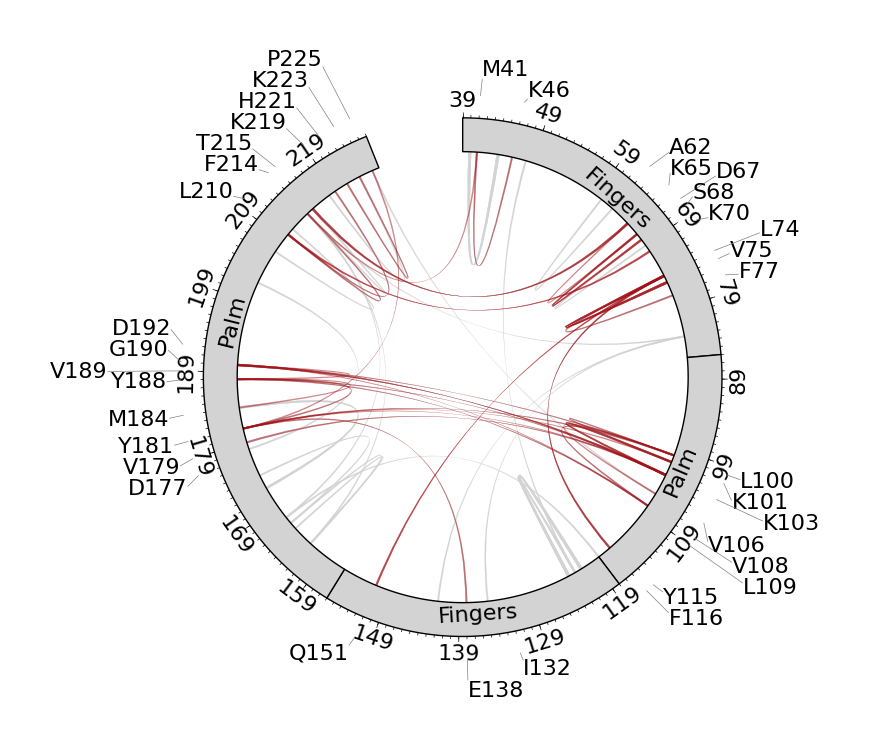

In [ ]:
# Save the plots as images
output_dir = '../ms0.5/Images/'

IN_circos_syn,sector =circ.initialize_IN_circos_w_ticks(actual_length_IN, (80, 92))
# circ.add_DRM_annotation(IN_circos_syn,sector, (100, 100),combined_DRM_IN)
# circ.connect_background_syn_cords(IN_circos_syn,sector,IN_kn_path, 50,1,0.5,'IN','color','global')
# circ.connect_syn_cords(IN_circos_syn,sector,IN_kn_path, top_20_DRM,IN_redux_dict,1,0.5,'color','global')
weight = 1
circ.connect_background_syn_cords(IN_circos_syn,sector,IN_kn_path, 50,1,width_d2,'IN',scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
circ.connect_syn_cords(IN_circos_syn,sector,IN_kn_path, top_20_DRM_IN,IN_redux_dict,1,width_d2,scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
fig = IN_circos_syn.plotfig()
fig.savefig(output_dir + 'IN_syn.png', dpi=450)  # Save the first figure (IN Syn) with dpi > 300

IN_circos_antag,sector =circ.initialize_IN_circos_w_ticks(actual_length_IN, (80, 92))
# circ.add_DRM_annotation(IN_circos_antag,sector, (100, 100),combined_DRM_IN)
# circ.connect_background_ant_cords(IN_circos_antag,sector,IN_kn_path, 50,1,0.5,'IN','color','global')
# circ.connect_ant_cords(IN_circos_antag,sector,IN_kn_path, bottom_20_DRM,IN_redux_dict,1,0.5,'color','global')
circ.connect_background_ant_cords(IN_circos_antag,sector,IN_kn_path, 50,1,width_d2,'IN',scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
circ.connect_ant_cords(IN_circos_antag,sector,IN_kn_path, bottom_20_DRM_IN,IN_redux_dict,1,width_d2,scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
fig = IN_circos_antag.plotfig()
fig.savefig(output_dir + 'IN_antag.png', dpi=450)  # Save the second figure (IN Antag)

weight = 99/263
PR_circos_syn,sector =circ.initialize_PR_circos_w_ticks(actual_length_PR, (80, 92))
# circ.add_DRM_annotation(PR_circos_syn,sector, (100, 100),combined_DRM_PR)
# circ.connect_background_syn_cords(PR_circos_syn,sector,PR_kn_path, 50,1,0.5*weight,'PR','color','global')
# circ.connect_syn_cords(PR_circos_syn,sector,PR_kn_path, top_20_DRM,PR_redux_dict,1,0.5*weight,'color','global')
circ.connect_background_syn_cords(PR_circos_syn,sector,PR_kn_path, 50,1,width_d2*weight,'PR',scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
circ.connect_syn_cords(PR_circos_syn,sector,PR_kn_path, top_20_DRM_PR,PR_redux_dict,1,width_d2*weight,scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
fig = PR_circos_syn.plotfig()
fig.savefig(output_dir + 'PR_syn.png', dpi=450)  # Save the third figure (PR Syn)

PR_circos_antag,sector =circ.initialize_PR_circos_w_ticks(actual_length_PR, (80, 92))
# circ.add_DRM_annotation(PR_circos_antag,sector, (100, 100),combined_DRM_PR)
weight = 99/263
# circ.connect_background_ant_cords(PR_circos_antag,sector,PR_kn_path, 50,1,0.5*weight,'PR','color','global')
# circ.connect_ant_cords(PR_circos_antag,sector,PR_kn_path, bottom_20_DRM,PR_redux_dict,1,0.5*weight,'color','global')
circ.connect_background_ant_cords(PR_circos_antag,sector,PR_kn_path, 50,1,1*weight,'PR',scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
circ.connect_ant_cords(PR_circos_antag,sector,PR_kn_path, bottom_20_DRM_PR,PR_redux_dict,1,1*weight,scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
fig = PR_circos_antag.plotfig()
fig.savefig(output_dir + 'PR_antag.png', dpi=450)  # Save the fourth figure (PR Antag)

RT_circos_syn,sector =circ.initialize_RT_circos_w_ticks(actual_length_RT, (80, 92))
# circ.add_DRM_annotation(RT_circos_syn,sector, (100, 100),combined_DRM_RT,39)
weight = 188/263
# circ.connect_background_syn_cords(RT_circos_syn,sector,RT_kn_path, 50,start_aa,0.5*weight, 'RT','color','global')
# circ.connect_syn_cords(RT_circos_syn,sector,RT_kn_path, top_20_DRM,RT_redux_dict,start_aa,0.5*weight,'color','global')
circ.connect_background_syn_cords(RT_circos_syn,sector,RT_kn_path, 50,start_aa_RT,width_d2*weight, 'RT',scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
circ.connect_syn_cords(RT_circos_syn,sector,RT_kn_path, top_20_DRM_RT,RT_redux_dict,start_aa_RT,width_d2*weight,scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
fig = RT_circos_syn.plotfig()
fig.savefig(output_dir + 'RT_syn.png', dpi=450)  # Save the fifth figure (RT Syn)

RT_circos_antag,sector =circ.initialize_RT_circos_w_ticks(actual_length_RT, (80, 92))
# circ.add_DRM_annotation(RT_circos_antag,sector, (100, 100),combined_DRM_RT, 39)
weight = 188/263
# circ.connect_background_ant_cords(RT_circos_antag,sector,RT_kn_path, 50,39,0.5*weight, 'RT','color','global')
# circ.connect_ant_cords(RT_circos_antag,sector,RT_kn_path, bottom_20_DRM,RT_redux_dict,39,0.5*weight,'color','global')
circ.connect_background_ant_cords(RT_circos_antag,sector,RT_kn_path, 50,39,width_d2*weight, 'RT',scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
circ.connect_ant_cords(RT_circos_antag,sector,RT_kn_path, bottom_20_DRM_RT,RT_redux_dict,39,width_d2*weight,scale_mode,scale_scale,weight_power,a,b,x_min,x_max,weight)
fig = RT_circos_antag.plotfig()
fig.savefig(output_dir + 'RT_antag.png', dpi=450)  # Save the sixth figure (RT Antag)


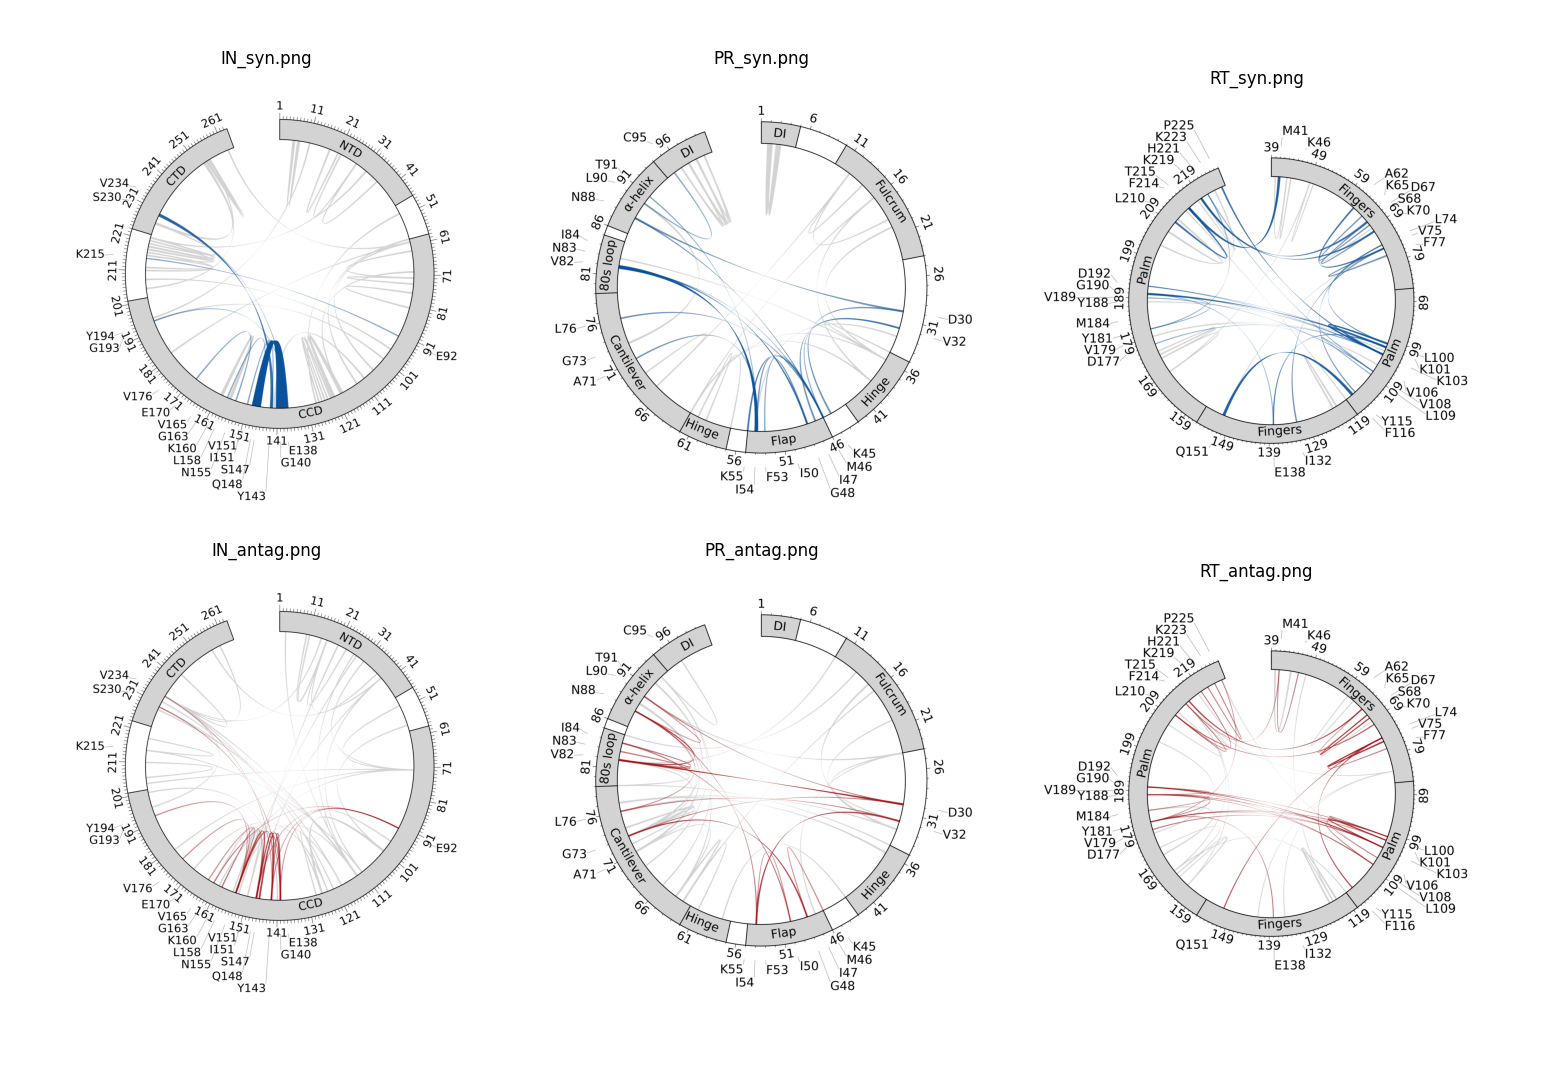

In [131]:
from PIL import Image

# Define the sequence of image filenames
image_files = ['IN_syn.png', 'PR_syn.png', 'RT_syn.png', 'IN_antag.png', 'PR_antag.png', 'RT_antag.png']

# Load the images
images = [Image.open(output_dir + img_file) for img_file in image_files]

# Create a new figure with subplots for the 6 images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot each image in its respective subplot
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.axis('off')  # Turn off axes for better visualization
    ax.set_title(f"{image_files[i]}")  # Set title based on the image number

# Adjust layout for better spacing
plt.tight_layout()
plt.show()
